[Vículo para evaluar la asesoría](https://forms.gle/jpywXvAAJC9L9mws9)

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/tools_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/tools_numpy.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

### [Vínculo al programa del curso:  ]()



Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = ''> 



## Título de la Asesoría: Modelado con funciones polinomiales 



Preparado de la página 159 del PreCálculo de Stewart: Ajuste Lineal de datos. 

# ENFOQUE SOBRE MODELADO    
## Ajuste lineal de datos  


# Modelado con funciones lineales  



Vamos a resolver el problema **como se haría en un cuaderno Jupyter**, combinando **análisis matemático + visualización con Python** usando:

* **Pandas** (tabla de datos)
* **Matplotlib** (visualización científica)
* **Plotly** (visualización interactiva)
* **ipywidgets** (exploración dinámica)

---



# Problema

Una bala de cañón disparada desde una batería costera sigue la trayectoria parabólica

$$
h(x) = 10x - 0.01x^2
$$

donde:

* $x$ = distancia horizontal recorrida (pies)
* $h(x)$ = altura de la bala sobre el mar (pies)



Se pide determinar:

**(a)** la altura máxima que alcanza la bala
**(b)** la distancia horizontal recorrida antes de caer al mar.

---



# 1. Interpretación matemática

La ecuación puede escribirse como

$$
h(x) = -0.01x^2 + 10x
$$

que es una **parábola cóncava hacia abajo**.

La altura máxima ocurre en el **vértice de la parábola**.



Para una función

$$
ax^2 + bx + c
$$

la primera coordenada del vértice es

$$
x_v = \frac{-b}{2a}
$$



En nuestro caso:

* $a=-0.01$
* $b=10$

Entonces

$$
x_v = \frac{-10}{2(-0.01)}
$$

$$
x_v = 500
$$



La altura máxima es

$$
h(500)=10(500)-0.01(500)^2
$$

$$
h(500)=5000-2500
$$

$$
h_{max}=2500 \text{ pies}
$$



✔ **Altura máxima:**

$$
\boxed{2500\ \text{pies}}
$$

---



# 2. Distancia horizontal antes de caer al agua

La bala cae cuando

$$
h(x)=0
$$

Entonces

$$
10x-0.01x^2=0
$$

Factorizamos:

$$
x(10-0.01x)=0
$$



Las soluciones son

$$
x=0
$$

y

$$
x=1000
$$

El valor relevante es

$$
\boxed{1000\ \text{pies}}
$$



✔ **La bala recorre 1000 pies horizontalmente.**

---



# 3. Crear una tabla con Pandas

```python


In [7]:
import pandas as pd
import numpy as np

x = np.arange(0,1000+100,100)

h = 10*x - 0.01*x**2

df = pd.DataFrame({
    "distancia_x":x,
    "altura_h":h
})

df.head(12)


,distancia_x,altura_h
0,0,0.0
1,100,900.0
2,200,1600.0
3,300,2100.0
4,400,2400.0
5,500,2500.0
6,600,2400.0
7,700,2100.0
8,800,1600.0
9,900,900.0



Esto genera una tabla de valores de la trayectoria.

---



# 4. Visualización con Matplotlib



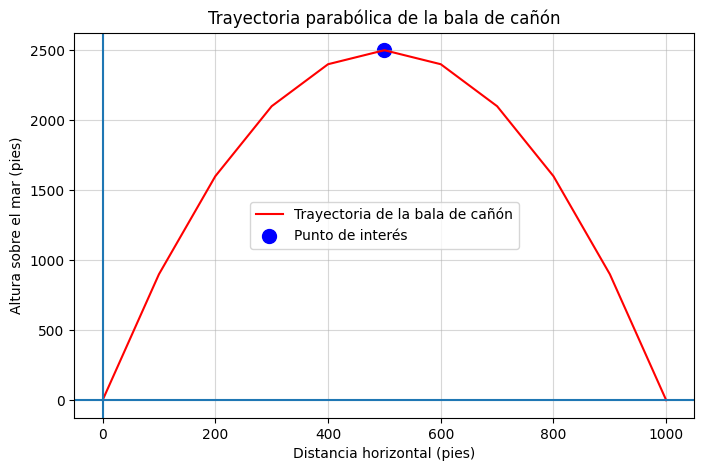

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df["distancia_x"],df["altura_h"], color = "red", label = "Trayectoria de la bala de cañón")
plt.scatter([500],[2500], color = "blue", s = 100, label = "Punto de interés")
plt.xlabel("Distancia horizontal (pies)")
plt.ylabel("Altura sobre el mar (pies)")
plt.legend()

plt.title("Trayectoria parabólica de la bala de cañón")

plt.axhline(0)
plt.axvline(0)
plt.grid(alpha = 0.5)
plt.savefig(r"C:\Users\marco\Downloads\trayectoria_parabolica.png", dpi=300, bbox_inches="tight")
plt.show()



En la gráfica se observa:

* el **punto máximo** $(500,2500)$
* el **punto donde cae** $(1000,0)$.

---



# 5. Visualización interactiva con Plotly



In [12]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=h,
        mode="lines",
        name="Trayectoria"
    )
)

fig.add_trace(
    go.Scatter(
        x=[500],
        y=[2500],
        mode="markers",
        name="Altura máxima"
    )
)

fig.update_layout(
    title="Trayectoria de la bala de cañón",
    xaxis_title="Distancia horizontal (pies)",
    yaxis_title="Altura (pies)"
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\trayectoria_parabolica_plotly.png", scale=3)



Esto permite **explorar la trayectoria de manera interactiva**.

---



# 6. Exploración con ipywidgets

Podemos mover un punto sobre la trayectoria.

```python


In [ ]:
from ipywidgets import interact

def altura(x):
    
    h = 10*x - 0.01*x**2
    
    plt.figure(figsize=(6,4))
    
    plt.plot(df["distancia_x"],df["altura_h"])
    
    plt.scatter(x,h,s=100)
    
    plt.xlabel("Distancia (pies)")
    plt.ylabel("Altura (pies)")
    
    plt.title("Exploración de la trayectoria")
    plt.savefig(r"C:\Users\marco\Downloads\trayectoria_parabolica_exploracion.png", dpi=300, bbox_inches="tight")
    plt.show()

interact(altura,x=(0,1000))


interactive(children=(IntSlider(value=500, description='x', max=1000), Output()), _dom_classes=('widget-intera…

<function __main__.altura(x)>


Los estudiantes pueden mover el deslizador y observar:

* cómo cambia la altura
* dónde ocurre el máximo
* dónde la altura vuelve a cero.

---



# 7. Interpretación física

La gráfica describe tres momentos importantes:

| Punto        | Interpretación    |
| ------------ | ----------------- |
| $(0,0)$      | disparo           |
| $(500,2500)$ | altura máxima     |
| $(1000,0)$   | impacto en el mar |

---



# 8. Resultado final

**Altura máxima**

$$
\boxed{2500\ \text{pies}}
$$

**Distancia horizontal recorrida**

$$
\boxed{1000\ \text{pies}}
$$

---


# Modelación de la página 322 del Precálculo de Stewart   

21. La resistencia $S$ de una viga de madera de ancho $x$ y profundidad y está dada por la fórmula $S = 13.8xy^{2}$. Se ha de cortar una viga de un tronco de 10 pulgadas de diámetro, como se muestra en la figura.  
  (a) Exprese la resistencia $S$ de esta viga como función sólo de x.  
  (b) ¿Cuál es el dominio de la función $S$?  
  (c) Trace una gráfica de $S$.  
  (d) ¿Qué ancho hará que sea más fuerte la viga?  


# 1. Interpretación geométrica del problema

El cobertizo tiene:

* **dos lados cuadrados**
* **parte superior rectangular**
* **parte posterior rectangular**
* **frente y fondo abiertos**

Definimos:

* $x$ = **profundidad del cobertizo (pulgadas)**
* $y$ = **ancho del cobertizo (pulgadas)**

Los extremos son **cuadrados de lado $x$**.


<img src = ''>


Entonces:

* área de cada extremo = $x^2$
* área de la parte superior = $xy$
* área posterior = $xy$

El material plástico cubre **4 lados**.

---



# 2. Restricción de área

El área total de plástico es

$$
1200\ \text{pulg}^2
$$



Entonces

$$
2x^2 + xy + xy = 1200
$$

$$
2x^2 + 2xy = 1200
$$



Dividimos entre 2:

$$
x^2 + xy = 600
$$



Despejamos $y$

$$
xy = 600 - x^2
$$

$$
y = \frac{600}{x} - x
$$

---



# 3. Función volumen

El cobertizo es un **prisma rectangular**

por lo tanto

$$
V = (\text{área base})(\text{profundidad})
$$

La base es un cuadrado $x \times x$.



Entonces

$$
V = x^2 y
$$

Sustituimos $y$

$$
V(x) = x^2\left(\frac{600}{x} - x\right)
$$



Simplificando

$$
V(x) = 600x - x^3
$$

Esta es la **función volumen**.

---



# 4. Imagen del cobertizo con Matplotlib

Este código genera una **visualización de la situación real**.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6,5))

# cara frontal (abierta)
rect1 = patches.Rectangle((0,0),4,4,fill=False)

# techo
rect2 = patches.Rectangle((0,4),4,2,fill=False)

# lado posterior
rect3 = patches.Rectangle((4,0),2,4,fill=False)

ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)

plt.text(1.5,-0.5,"frente abierto")
plt.text(1.7,4.8,"techo")
plt.text(4.3,1.5,"parte posterior")

plt.title("Cobertizo para plantas delicadas")

plt.xlim(-1,7)
plt.ylim(-1,7)

plt.axis("off")
plt.savefig(r"C:\Users\marco\Downloads\cobertizo.png", dpi=300, bbox_inches="tight")
plt.show()


Esto permite que los estudiantes **visualicen el modelo geométrico**.

---



# 5. Construcción de datos con Pandas



In [ ]:
import pandas as pd
import numpy as np

x = np.linspace(1,30,200)

V = 600*x - x**3

df = pd.DataFrame({
    "profundidad":x,
    "volumen":V
})

df.head()



# 6. Gráfica con Matplotlib


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(df["profundidad"],df["volumen"])

plt.xlabel("Profundidad x (pulgadas)")
plt.ylabel("Volumen V")

plt.title("Volumen del cobertizo")
plt.savefig(r"C:\Users\marco\Downloads\volumen_cobertizo.png", dpi=300, bbox_inches="tight")
plt.show()



La gráfica representa

$$
V(x) = 600x - x^3
$$

---



# 7. Cálculo del volumen máximo

Derivamos

$$
V'(x) = 600 - 3x^2
$$



Máximo cuando

$$
600 - 3x^2 = 0
$$

$$
x^2 = 200
$$

$$
x = \sqrt{200}
$$

$$
x \approx 14.14
$$

---



# 8. Dimensiones óptimas

Profundidad

$$
x \approx 14.14\ \text{pulg}
$$

Ahora calculamos el ancho

$$
y = \frac{600}{x} - x
$$



In [ ]:
import numpy as np

x_opt = np.sqrt(200)

y_opt = 600/x_opt - x_opt

V_max = 600*x_opt - x_opt**3

x_opt, y_opt, V_max


Resultado aproximado

| variable        | valor          |
| --------------- | -------------- |
| profundidad $x$ | **14.14 pulg** |
| ancho $y$       | **28.28 pulg** |
| volumen máximo  | **5656 pulg³** |



---

# 9. Visualización interactiva con Plotly

In [ ]:
import plotly.express as px

fig = px.line(
    df,
    x="profundidad",
    y="volumen",
    title="Volumen del cobertizo"
)

fig.show()



# 10. Exploración con ipywidgets

Esto permite que los estudiantes **exploren el volumen variando la profundidad**.



In [ ]:
from ipywidgets import interact

def volumen(x):
    
    V = 600*x - x**3
    
    plt.figure(figsize=(6,4))
    
    plt.plot(df["profundidad"],df["volumen"])
    
    plt.scatter(x,V,s=100)
    
    plt.xlabel("profundidad")
    plt.ylabel("volumen")
    
    plt.title("Exploración del volumen")
    plt.savefig(r"C:\Users\marco\Downloads\volumen_cobertizo_exploracion.png", dpi=300, bbox_inches="tight")
    plt.show()

interact(volumen,x=(1,30))




# 11. Resultado final

El volumen máximo ocurre cuando

$$
x = \sqrt{200} \approx 14.14
$$



Las dimensiones óptimas del cobertizo son

**profundidad**

$$
14.14 \text{ pulg}
$$

**ancho**

$$
28.28 \text{ pulg}
$$

**altura**

$$
14.14 \text{ pulg}
$$

**volumen máximo**

$$
V_{max} \approx 5656\ \text{pulg}^3
$$

---



# **Interpretación física**

El cobertizo debe ser aproximadamente:

* **14 pulg de alto**
* **14 pulg de profundidad**
* **28 pulg de ancho**

para aprovechar al máximo los **1200 pulg² de plástico**.

---


# 


# Enfoque sobre modelado

## Ajuste lineal de datos

Un **modelo** es una representación simplificada de un objeto o de un proceso real. Por ejemplo:

* Un automóvil de juguete es un modelo de un automóvil real.
* Un mapa de carreteras es un modelo de las calles de una ciudad.

De forma análoga, un **modelo matemático** es una representación matemática (generalmente mediante ecuaciones o funciones) de un fenómeno real.

Un modelo matemático permite:

* describir relaciones entre variables,
* comprender patrones en los datos,
* realizar **predicciones** sobre valores futuros.

En esta sección exploramos cómo usar las matemáticas para **modelar relaciones entre variables a partir de datos experimentales**.

---



# La recta que mejor se ajusta a los datos

En muchas situaciones reales existe una relación aproximadamente lineal entre dos variables.

Por ejemplo, en un estudio sobre obesidad infantil se puede analizar la relación entre:

* $x$ : número de horas al día viendo televisión
* $y$ : índice de masa corporal (BMI)

En la práctica, los datos **no caen exactamente sobre una recta**, sino que presentan dispersión.

Por ello se utiliza un **modelo lineal aproximado**

$$
y = mx + b
$$

donde

* $m$ es la **pendiente**
* $b$ es la **intersección con el eje $y$**

La recta que describe mejor la tendencia de los datos se denomina **recta de regresión** o **recta de mejor ajuste**.

---



# Ejemplo 1

## Mortalidad infantil

La siguiente tabla muestra la tasa de mortalidad infantil en Estados Unidos entre 1950 y 2000.

| Año  | Tasa |
| ---- | ---- |
| 1950 | 29.2 |
| 1960 | 26.0 |
| 1970 | 20.0 |
| 1980 | 12.6 |
| 1990 | 9.2  |
| 2000 | 6.9  |

Para simplificar el análisis definimos

$$
x = \text{años desde 1950}
$$

por lo que

| Año  | $x$ |
| ---- | --- |
| 1950 | 0   |
| 1960 | 10  |
| 1970 | 20  |
| 1980 | 30  |
| 1990 | 40  |
| 2000 | 50  |

---



# Análisis con Python

## 1. Cargar los datos con Pandas

```python


In [ ]:
import pandas as pd

data = {
    "year":[1950,1960,1970,1980,1990,2000],
    "mortality":[29.2,26.0,20.0,12.6,9.2,6.9]
}

df = pd.DataFrame(data)

df["x"] = df["year"] - 1950

df



# Gráfica de dispersión con Matplotlib

```python


In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["x"], df["mortality"])

plt.xlabel("Años desde 1950")
plt.ylabel("Tasa de mortalidad infantil")

plt.title("Mortalidad infantil en Estados Unidos")

plt.show()



La gráfica de dispersión sugiere una **tendencia lineal decreciente**.

---



# Cálculo de la recta de regresión

Podemos calcular los parámetros de la recta con **NumPy**.

```python


In [ ]:
import numpy as np

x = df["x"]
y = df["mortality"]

m, b = np.polyfit(x, y, 1)

print(m,b)



La ecuación obtenida es aproximadamente

$$
y = -0.48x + 29.4
$$

---



# Gráfica con la recta de regresión

```python


In [ ]:
y_pred = m*x + b

plt.scatter(x,y,label="Datos")
plt.plot(x,y_pred,label="Recta de regresión")

plt.xlabel("Años desde 1950")
plt.ylabel("Tasa de mortalidad infantil")

plt.legend()

plt.show()



# Visualización interactiva con Plotly

```python


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="markers",
        name="Datos"
    )
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y_pred,
        mode="lines",
        name="Recta de regresión"
    )
)

fig.update_layout(
    title="Regresión lineal mortalidad infantil",
    xaxis_title="Años desde 1950",
    yaxis_title="Tasa de mortalidad infantil"
)

fig.show()



# Predicciones usando el modelo

### Año 1995

1995 corresponde a

$$
x = 45
$$

Entonces

$$
y = -0.48(45) + 29.4
$$

$$
y \approx 7.8
$$

---



### Año 2006

2006 corresponde a

$$
x = 56
$$

$$
y = -0.48(56) + 29.4
$$

$$
y \approx 2.5
$$

Sin embargo, el valor real fue aproximadamente **6.4**.

Esto muestra un aspecto importante del modelado:

⚠ **Extrapolar fuera del rango de los datos puede producir errores significativos.**

---



# Método de mínimos cuadrados

La recta de regresión se obtiene minimizando

$$
S = \sum (y_i - \hat{y_i})^2
$$

donde

* $y_i$ son los valores observados
* $\hat{y_i}$ son los valores predichos

Este método se denomina **método de mínimos cuadrados**.

---



# Ejemplo 2

## Salto con pértiga en Juegos Olímpicos

El rendimiento en salto con pértiga ha mejorado a lo largo del tiempo.

Si definimos

$$
x = \text{año} - 1900
$$

y $y$ como la altura en metros, se obtiene el modelo

$$
y = 0.0266x + 3.40
$$

La pendiente

$$
m = 0.0266
$$

significa que el récord aumenta en promedio

$$
0.0266 \text{ metros por año}
$$

---



# Coeficiente de correlación

Para evaluar qué tan bien se ajusta el modelo lineal se utiliza el **coeficiente de correlación** $r$.

$$
-1 \le r \le 1
$$



Interpretación:

| Valor de $r$   | Interpretación              |
| -------------- | --------------------------- |
| $r \approx 1$  | correlación positiva fuerte |
| $r \approx -1$ | correlación negativa fuerte |
| $r \approx 0$  | poca o ninguna correlación  |

---



# Cálculo del coeficiente de correlación con Pandas



In [ ]:
df[["x","mortality"]].corr()


```

Si

$$
r \approx -0.99
$$

entonces existe una **correlación lineal muy fuerte**.

---



# Correlación no implica causalidad

Es importante recordar que

**correlación no implica causalidad**.

Por ejemplo:

* el tamaño del calzado y el rendimiento en matemáticas pueden estar correlacionados en niños,
* pero esto ocurre porque **ambos aumentan con la edad**.

Por tanto, la correlación es una herramienta para **detectar relaciones**, pero no demuestra necesariamente **causa y efecto**.

---



# Actividades para los estudiantes

### 1. Longitud del fémur y estatura

Use Python para:

1. crear un DataFrame con los datos
2. hacer la gráfica de dispersión
3. calcular la recta de regresión
4. estimar la estatura para un fémur de 58 cm.

---



### 2. Temperatura y ventas de gaseosas

Repita el proceso:

* gráfica de dispersión
* recta de regresión
* predicción para $95^\circ F$.

---



### 3. Temperatura y chirridos de grillos

Estime la frecuencia de chirridos para

$$
100^\circ F
$$

---



# Conclusión

El **ajuste lineal de datos** es una herramienta fundamental para:

* describir relaciones entre variables,
* construir modelos matemáticos,
* realizar predicciones.

En ciencia de datos y aprendizaje automático, la **regresión lineal** constituye uno de los modelos más importantes y sirve como base para técnicas más avanzadas.

---


Preparado de la página 325 del precálculo de Stewart  

Ajuste de datos a curvas con funciones polinomiales

# Problema de modelación con funciones cúbicas  
Problema tomado del PreCálculo de Stewart página del PDF 322. 

<img src = 'problema_modelacion_funcion_cubica_cobertizo.png'>


[Video de apoyo a la solución de este problema](https://www.youtube.com/watch?v=fGpnGgJN7pQ)


Resolvamos el problema combinando herramientas de **modelación simbólica**, **optimización** y **ajuste polinomial** usando:

* SymPy
* SciPy
* Matplotlib
* Plotly

---



# 1. Modelo matemático

Sea:

* $x$ = lado del extremo cuadrado
* $y$ = profundidad del cobertizo



Los **cuatro lados de plástico** son:

1. dos cuadrados: $x^2$
2. parte superior: (x y)
3. parte posterior: (x y)



Área total:

$$
2x^2 + 2xy = 1200
$$

De aquí despejamos (y):

$$
y = \frac{600 - x^2}{x}
$$

---



# 2. Volumen como función de (x)

El volumen del cobertizo es

$$
V = x^2 y
$$

Sustituyendo $y$:

$$
V(x) = x^2\left(\frac{600-x^2}{x}\right)
$$

$$
V(x) = 600x - x^3
$$

---

# 3. Solución simbólica con Python

```python


import sympy as sp

x = sp.symbols('x', positive=True)

V = 600*x - x**3

dV = sp.diff(V, x)

criticos = sp.solve(dV, x)

criticos


```

Resultado:

$$
x = \sqrt{200}
$$

---

# 4. Dimensiones óptimas

```python


In [ ]:
x_opt = sp.sqrt(200)

y_opt = (600 - x_opt**2)/x_opt

V_max = V.subs(x, x_opt)

float(x_opt), float(y_opt), float(V_max)


```

Resultado aproximado:

$$
x \approx 14.14
$$

$$
y \approx 28.28
$$

$$
V_{max} \approx 5656.85
$$

---

- **Dimensiones que maximizan el volumen**

| dimensión   | valor      |
| ----------- | ---------- |
| ancho       | 14.14 pulg |
| altura      | 14.14 pulg |
| profundidad | 28.28 pulg |

---

# 5. Generar datos artificiales del volumen

```python


import numpy as np
import pandas as pd

x_vals = np.linspace(1,30,50)

V_vals = 600*x_vals - x_vals**3

df = pd.DataFrame({
    "x": x_vals,
    "V": V_vals
})

df.head()


```

---



# 6. Regresión polinomial

```python


from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(df[["x"]])

modelo = LinearRegression()

modelo.fit(X_poly, df["V"])

print(modelo.coef_)


```

---



# 7. Gráfica con Matplotlib

```python


import matplotlib.pyplot as plt

plt.figure()

plt.scatter(x_vals, V_vals)

plt.plot(x_vals, V_vals)

plt.axvline(float(x_opt))

plt.xlabel("Profundidad x")

plt.ylabel("Volumen")

plt.title("Volumen del cobertizo")

plt.grid()

plt.show()


```

---



# 8. Gráfica interactiva

```python


import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_vals,
    y=V_vals,
    mode='lines',
    name="V(x)"
))

fig.add_trace(go.Scatter(
    x=[float(x_opt)],
    y=[float(V_max)],
    mode='markers',
    marker=dict(size=10),
    name="Máximo"
))

fig.update_layout(
    title="Volumen del cobertizo",
    xaxis_title="x",
    yaxis_title="V(x)"
)

fig.show()


```

---



# 9. Verificación numérica con SciPy

```python


In [1]:
from scipy.optimize import minimize_scalar

def V_func(x):
    return -(600*x - x**3)

res = minimize_scalar(V_func)

res.x, -res.fun


ModuleNotFoundError: No module named 'scipy'

```

Esto confirma el máximo en

$$
x \approx 14.14
$$

---



# 10. Interpretación geométrica (muy útil para estudiantes)

La función

$$
V(x) = 600x - x^3
$$

es un **polinomio cúbico** cuyo máximo representa el equilibrio entre:

* aumentar profundidad
* reducir tamaño de las caras cuadradas debido al límite de área.

---



- **Conclusión**

El volumen máximo ocurre cuando

$
x = \sqrt{200}, \quad y = 2\sqrt{200}
$

y el volumen máximo es aproximadamente

$$
V_{max} \approx 5656.85 \text{ pulg}^3
$$

---



💡 Si quieres, puedo darte también una **versión tipo cuaderno Jupyter para clase** con:

* **slider interactivo de (x)**
* visualización **3D del cobertizo**
* cálculo automático del volumen

(lo cual queda muy impactante cuando enseñas **optimización en cálculo**).


### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

# Horario de clases del profesor Marco

* Lunes 8-12: Asesoría Janis Trabajo de Grado. 
* Martes 8-12 M: . 
* Martes: 2-6: Álgebra Lineal. 
* Miércoles 8 a 12 M: 
* Miércoles de 2 a 6 PM. 
* Jueves de 8 AM a 12 M: Fundamentos de programación. 
* Jueves 2 a 6 PM: . 
* Viernes 8 - 12 M: Asesorías y espacio para retroalimentación y apoyo al trabajo independiente. 
* Viernes de 2 a 3 PM: Reunión semanal del grupo SAT Dengue. 
* Viernes de 3 a 6 PM: 
* Sábados 8-12:  

## Referentes 

* [Cómo enseñar con cuadernos Jupyter](https://jupyter4edu.github.io/jupyter-edu-book/)  
  


* [Cómo enseñar matemáticas con calculadora Casio LA991 cw](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://bibliotecadigital.udea.edu.co/bitstream/10495/32857/4/ParraZapata_2024_DesarrolloPensamientoMatematico2aed_versionweb.pdf)  

* [CALCULO I DE UNA VARIABLE Ron Larson-Bruce Edwards. Mc Graw Hill. 9º Edición](https://www.academia.edu/42139251/CALCULO_I_DE_UNA_VARIABLE_Ron_Larson_Bruce_Edwards_Mc_Graw_Hill_9o_Edici%C3%B3n)   
  



* [Grajales Vanegas, L. M., Restrepo Estrada, C. E., Restrepo Ochoa, S. I., & Ruíz De Villalba, F. (2015). Matemáticas I para las ciencias económicas.](https://bibliotecadigital.udea.edu.co/handle/10495/3010)


  
* R. Duval y Semiosis y pensamiento humano, 2.ª ed. Cali, Colombia: Programa Editorial Universidad del Valle, 2017. [En línea]. Disponible en: https://programaeditorial.univalle.edu.co/gpd-semiosis-y-pensamiento-humano-9789587655278-63324cdb0f6b3.html



* [Aylwin, C. U. (2011). Lógica, conjuntos y números. Universidad de los Andes, Consejo de Publicaciones, Colección: Ciencias Básicas, Serie: Matemáticas.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.u-cursos.cl/ciencias/2011/1/MC110/1/material_docente/bajar?id_material=574722)
  


* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)




* [Géron, A. (2017). Hands-on machine learning with scikit-learn and tensorflow: Concepts. Tools, and Techniques to build intelligent systems.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)   



* [McKinney, W. (2012). Python for data analysis: Data wrangling with Pandas, NumPy, and IPython. " O'Reilly Media, Inc.".](https://wesmckinney.com/book/) 

# Como estudiante, encuentro que...   

F: Mis Fortalezas son:     
O: Mis Oportunidades son:    
D: Mis Debilidades son:    
A: Lo que Amenazas mi aprendizaje es:  

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

## Agradecimientos  

Doy gracias a Dios por la vida de mi Hijo Joseph Cañas Osorio y la madurez que ha alcanzado. Este hijo me enorgullece y me hace falta abrazarlo cada día. 

Y a mi esposa Yasmira Emperatriz Barboza Mogollón por su apoyo, orientación y acompañamiento. 